# GLM-4.7-Flash REAP Pruning v2

**REAP** (Router-weighted Expert Activation Pruning) for MoE models.

- **Method**: [CerebrasResearch/reap](https://github.com/CerebrasResearch/reap)
- **Paper**: [arXiv:2510.13999](https://arxiv.org/abs/2510.13999)
- **Formula**: 

**Pipeline:**
- Base:  (64 experts, 47 layers, ~30B total, ~3B active)
- Architecture: Layer 0 = dense MLP, Layers 1-46 = MoE (46 MoE layers)
- Routing: **sigmoid** (DeepSeek-V3 style) with , NOT softmax
- Target: **20% pruning** -> 51 experts per MoE layer
- Calibration: STEM-focused dataset (**deduplicated**, balanced RU/EN)
- Output: GGUF for Ollama/llama.cpp

**Key implementation details:**
- float64 accumulation on CPU (prevents NaN from bf16 overflow)
- Correct sigmoid routing matching GLM-4.7-Flash source code
- Per-layer pruning (different experts pruned per layer)
- Manual safetensors fallback if  fails
- **Dataset deduplication** -- removes 600 duplicate samples that skewed EN/RU balance

**Requirements:** A100 80GB recommended (fits entirely on GPU). A100 40GB works with CPU offloading.

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {gpu_mem:.1f} GB')
    assert gpu_mem >= 35, 'A100 40GB+ required!'
else:
    raise RuntimeError('No CUDA GPU!')

name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB
PyTorch: 2.9.0+cu126
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.2 GB


In [2]:
!pip uninstall -y tensorflow tensorflow-cpu tf-keras -q 2>/dev/null || true
!pip install -q --upgrade pip
!pip install -q datasets huggingface_hub accelerate sentencepiece tqdm safetensors matplotlib psutil
!pip install -q git+https://github.com/huggingface/transformers.git

import transformers
print(f'[OK] transformers: {transformers.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 79.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
[OK] transformers: 5.2.0.dev0


In [3]:
from huggingface_hub import login
login()

!mkdir -p /content/models /content/outputs /content/gguf
print('[OK] Ready')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


[OK] Ready


In [4]:
from huggingface_hub import snapshot_download
from transformers import AutoConfig
import os

MODEL_ID = 'zai-org/GLM-4.7-Flash'
MODEL_PATH = '/content/models/glm-4.7-flash'

if not os.path.exists(f'{MODEL_PATH}/config.json'):
    print(f'Downloading {MODEL_ID}...')
    snapshot_download(
        repo_id=MODEL_ID,
        local_dir=MODEL_PATH,
        ignore_patterns=['*.gguf', '*.md', '*.txt']
    )

config = AutoConfig.from_pretrained(MODEL_PATH, trust_remote_code=True)
print(f'Model: {config.model_type}')
print(f'Experts: {config.n_routed_experts}')
print(f'Layers: {config.num_hidden_layers}')
print(f'Active/token: {config.num_experts_per_tok}')
print(f'Hidden size: {config.hidden_size}')

Fetching 57 files:   0%|          | 0/57 [00:00<?, ?it/s]

Model: glm4_moe_lite
Experts: 64
Layers: 47
Active/token: 4
Hidden size: 2048


## REAP Observer

Based on the official [CerebrasResearch/reap](https://github.com/CerebrasResearch/reap) observer.

**REAP saliency** for expert `j` in layer `l`:
```
S(l,j) = (1/N_j) * sum_{x in X_j} g_j(x) * ||f_j(x)||_2
```
- `g_j(x)` = normalized sigmoid gate value for expert j on token x
- `f_j(x)` = expert j output vector for token x
- `N_j` = number of tokens routed to expert j

**GLM-4.7-Flash routing (DeepSeek-V3 style):**
- Router outputs raw logits via `F.linear(hidden, weight)`
- Gate values: `sigmoid(logits)` (NOT softmax)
- Expert selection: `topk(sigmoid + e_score_correction_bias)` (bias corrects load balance)
- Gate normalization: `g_selected / sum(g_selected)` then scale by `routed_scaling_factor=1.8`
- We use **unbiased sigmoid values** for REAP saliency (bias only affects selection)

**Key fixes vs v1:**
- All accumulation in float64 on CPU (prevents NaN from bf16 overflow)
- Correct sigmoid routing (v1 used softmax — wrong for GLM-4.7-Flash)
- Auto-detect weight layout: `[n_exp, out, in]` vs `[n_exp, in, out]`
- Per-layer saliency (different experts pruned per layer)
- NaN guards on every accumulation step

In [5]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import gc
import json
import os
import time


class REAPObserver:
    """
    REAP saliency observer for GLM-4.7-Flash (fused MoE, sigmoid routing).

    GLM-4.7-Flash uses DeepSeek-V3 style routing:
      - sigmoid(logits) for gate values (NOT softmax)
      - topk(sigmoid + e_score_correction_bias) for expert selection
      - normalize selected gate values, then scale by routed_scaling_factor

    Reference: https://github.com/CerebrasResearch/reap/blob/main/src/reap/observer.py
    """

    def __init__(self, model, num_layers, num_experts, num_experts_per_tok):
        self.model = model
        self.num_layers = num_layers
        self.num_experts = num_experts
        self.num_experts_per_tok = num_experts_per_tok

        # Accumulate on CPU in float64 — prevents NaN/overflow
        self.reap_sum = torch.zeros(num_layers, num_experts, dtype=torch.float64)
        self.ean_sum  = torch.zeros(num_layers, num_experts, dtype=torch.float64)
        self.freq     = torch.zeros(num_layers, num_experts, dtype=torch.int64)
        self.total_tokens = 0

        self.hooks = []
        self._weight_fmt = None  # auto-detected
        self._nan_count = 0
        self._hook_errors = 0

    def _detect_weight_format(self, experts):
        """Detect if gate_up_proj is [n, out, in] or [n, in, out]."""
        w = experts.gate_up_proj[0]
        if w.shape[0] > w.shape[1]:
            self._weight_fmt = 'linear'   # [out, in] -> F.linear
        else:
            self._weight_fmt = 'matmul'   # [in, out] -> matmul
        print(f'  gate_up_proj shape: {list(experts.gate_up_proj.shape)}')
        print(f'  Per-expert: {list(w.shape)} -> format: {self._weight_fmt}')

    def _expert_norm(self, hidden_f32, experts, idx):
        """Compute ||f_j(x)||_2 for expert j. All math in float32."""
        gup_w = experts.gate_up_proj[idx].float()
        dwn_w = experts.down_proj[idx].float()

        if self._weight_fmt == 'linear':
            gup = F.linear(hidden_f32, gup_w)
        else:
            gup = torch.matmul(hidden_f32, gup_w)

        mid = gup.shape[-1] // 2
        act = F.silu(gup[..., :mid]) * gup[..., mid:]

        if self._weight_fmt == 'linear':
            out = F.linear(act, dwn_w)
        else:
            out = torch.matmul(act, dwn_w)

        return torch.linalg.norm(out, dim=-1)

    def _create_hook(self, layer_idx):
        def hook_fn(module, args, output):
            try:
                with torch.no_grad():
                    hidden = args[0]
                    if hidden.dim() == 3:
                        hidden = hidden.reshape(-1, hidden.size(-1))

                    n_tok = hidden.size(0)
                    self.total_tokens += n_tok

                    if self._weight_fmt is None:
                        self._detect_weight_format(module.experts)

                    # ── GLM-4.7-Flash routing: sigmoid + bias ──
                    # 1. Raw logits from router
                    logits = module.gate(hidden)           # [n_tok, n_experts]

                    # 2. Sigmoid gate values (NOT softmax!)
                    sigmoid_vals = logits.float().sigmoid() # [n_tok, n_experts]

                    # 3. Expert selection uses sigmoid + correction bias
                    #    (bias improves load balance but shouldn't affect saliency score)
                    selection_scores = sigmoid_vals
                    if hasattr(module.gate, 'e_score_correction_bias'):
                        selection_scores = sigmoid_vals + module.gate.e_score_correction_bias.float()

                    _, topk_idx = torch.topk(
                        selection_scores, self.num_experts_per_tok, dim=-1
                    )  # [n_tok, k]

                    # 4. Gate values for REAP: normalized sigmoid (no bias)
                    #    Model does: gather → normalize → scale by routed_scaling_factor
                    #    For REAP saliency we use normalized gate values (pre-scaling)
                    topk_sigmoid = sigmoid_vals.gather(1, topk_idx)  # [n_tok, k]
                    topk_weights = topk_sigmoid / (topk_sigmoid.sum(dim=-1, keepdim=True) + 1e-20)

                    hidden_f32 = hidden.float()

                    # ── Accumulate per-expert saliency ──
                    unique_experts = topk_idx.unique().tolist()
                    for eidx in unique_experts:
                        # Find tokens where this expert is selected
                        expert_positions = (topk_idx == eidx)  # [n_tok, k] bool
                        mask = expert_positions.any(dim=-1)     # [n_tok] bool
                        cnt = mask.sum().item()
                        if cnt == 0:
                            continue

                        active_h = hidden_f32[mask]

                        # Get normalized gate value for this expert
                        # For each token, find the slot where this expert was selected
                        gate_vals = (topk_weights[mask] * expert_positions[mask].float()).sum(dim=-1)

                        norms = self._expert_norm(active_h, module.experts, eidx)

                        if torch.isnan(norms).any() or torch.isinf(norms).any():
                            self._nan_count += 1
                            continue

                        reap = (gate_vals * norms).sum().cpu().to(torch.float64)
                        ean  = norms.sum().cpu().to(torch.float64)

                        self.reap_sum[layer_idx, eidx] += reap
                        self.ean_sum[layer_idx, eidx]  += ean
                        self.freq[layer_idx, eidx]     += cnt

            except Exception as e:
                self._hook_errors += 1
                if self._hook_errors <= 3:
                    print(f'  Hook error layer {layer_idx}: {e}')

        return hook_fn

    def register_hooks(self):
        """Register hooks on MoE layers only (skips dense layer 0)."""
        count = 0
        for i in range(self.num_layers):
            layer = self.model.model.layers[i]
            if hasattr(layer, 'mlp') and hasattr(layer.mlp, 'experts'):
                h = layer.mlp.register_forward_hook(self._create_hook(i))
                self.hooks.append(h)
                count += 1
        print(f'Registered {count} hooks (on MoE layers, skipping dense)')

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks.clear()

    def get_saliency(self, method='reap'):
        """Returns [num_layers, num_experts] saliency tensor."""
        safe_freq = self.freq.clamp(min=1).double()
        if method == 'reap':
            return (self.reap_sum / safe_freq).float()
        elif method == 'ean':
            return (self.ean_sum / safe_freq).float()
        elif method == 'frequency':
            return self.freq.float()
        raise ValueError(f'Unknown: {method}')

    def get_experts_to_prune(self, n_to_prune, method='reap'):
        """Per-layer dict: layer_idx -> list of expert indices to prune."""
        sal = self.get_saliency(method)
        result = {}
        for li in range(self.num_layers):
            if self.freq[li].sum() == 0:
                continue
            _, bottom = torch.topk(sal[li], n_to_prune, largest=False)
            result[li] = sorted(bottom.tolist())
        return result

print('[OK] REAPObserver defined (sigmoid routing, GLM-4.7-Flash)')

[OK] REAPObserver defined (sigmoid routing, GLM-4.7-Flash)


In [6]:
def prune_model(model, to_prune, target_n_experts):
    """
    Prune fused MoE experts in-place, per layer.
    Reference: https://github.com/CerebrasResearch/reap/blob/main/src/reap/prune.py
    """
    for layer_idx, prune_indices in tqdm(to_prune.items(), desc='Pruning'):
        moe = model.model.layers[layer_idx].mlp
        if not hasattr(moe, 'experts'):
            continue

        current_n = moe.experts.gate_up_proj.shape[0]
        retained = [i for i in range(current_n) if i not in set(prune_indices)]

        # Slice fused expert tensors
        moe.experts.gate_up_proj.data = moe.experts.gate_up_proj.data[retained]
        moe.experts.down_proj.data    = moe.experts.down_proj.data[retained]

        # Slice router weights
        moe.gate.weight.data = moe.gate.weight.data[retained]
        if hasattr(moe.gate, 'bias') and moe.gate.bias is not None:
            moe.gate.bias.data = moe.gate.bias.data[retained]
        if hasattr(moe.gate, 'e_score_correction_bias'):
            moe.gate.e_score_correction_bias.data = (
                moe.gate.e_score_correction_bias.data[retained]
            )

        if hasattr(moe, 'n_routed_experts'):
            moe.n_routed_experts = len(retained)

    model.config.n_routed_experts = target_n_experts
    print(f'Pruned to {target_n_experts} experts/layer')

print('[OK] prune_model defined')

[OK] prune_model defined


## Configuration & Calibration

In [7]:
MODEL_PATH          = '/content/models/glm-4.7-flash'
OUTPUT_DIR          = '/content/outputs/glm-reap-51exp'
DATASET_ID          = 'Siesher/mits-calibration-dataset'
COMPRESSION_RATIO   = 0.20     # 20% pruning (was 30%)
N_CALIB_SAMPLES     = 768      # more samples after dedup (was 512)
PRUNE_METHOD        = 'reap'   # reap | ean | frequency
HF_REPO             = 'Siesher/glm-reap-51exp-gguf'

from transformers import AutoConfig
cfg = AutoConfig.from_pretrained(MODEL_PATH, trust_remote_code=True)
NUM_EXPERTS     = cfg.n_routed_experts
NUM_LAYERS      = cfg.num_hidden_layers
NUM_PER_TOK     = cfg.num_experts_per_tok
TARGET_EXPERTS  = int(NUM_EXPERTS * (1 - COMPRESSION_RATIO))
N_TO_PRUNE      = NUM_EXPERTS - TARGET_EXPERTS

print(f'Experts: {NUM_EXPERTS} -> {TARGET_EXPERTS}  (prune {N_TO_PRUNE}/layer, {COMPRESSION_RATIO*100:.0f}%)')
print(f'Calibration: {N_CALIB_SAMPLES} samples (deduplicated)')

Experts: 64 -> 51  (prune 13/layer, 20%)
Calibration: 768 samples (deduplicated)


In [8]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import psutil

gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
cpu_mem = psutil.virtual_memory().available / (1024**3)
print(f'GPU: {gpu_mem:.1f} GB | CPU RAM: {cpu_mem:.1f} GB')

# GLM-4.7-Flash: ~30B params, ~60GB in bf16
MODEL_BF16_GB = 60

if gpu_mem >= MODEL_BF16_GB * 1.1:
    # A100 80GB: entire model fits on GPU
    print(f'\n[A100-80GB mode] Loading entirely on GPU')
    load_kwargs = dict(
        dtype=torch.bfloat16,
        device_map={'': 0},
        trust_remote_code=True,
    )
else:
    # A100 40GB: split across GPU + CPU RAM
    total_mem = gpu_mem + cpu_mem
    print(f'\n[Split mode] GPU + CPU RAM ({total_mem:.0f} GB total)')
    if total_mem < MODEL_BF16_GB * 1.1:
        print('[WARNING] Enable "High-RAM runtime" in Colab!')
    load_kwargs = dict(
        dtype=torch.bfloat16,
        device_map='auto',
        trust_remote_code=True,
        max_memory={
            0: f'{int(gpu_mem * 0.82)}GiB',
            'cpu': f'{int(cpu_mem * 0.75)}GiB',
        },
        # NO offload_folder — avoids meta-device params that break forward pass
    )

print('Loading model...')
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, **load_kwargs)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.eval()

print(f'\nClass: {model.__class__.__name__}')
if hasattr(model, 'hf_device_map'):
    dev_counts = {}
    for k, v in model.hf_device_map.items():
        dev_counts[str(v)] = dev_counts.get(str(v), 0) + 1
    for dev, cnt in sorted(dev_counts.items()):
        print(f'  Device {dev}: {cnt} modules')
else:
    print(f'  Device: {model.device} (entire model)')

meta_params = [n for n, p in model.named_parameters() if p.device.type == 'meta']
if meta_params:
    print(f'\n[DANGER] {len(meta_params)} params on meta device!')
else:
    print(f'[OK] All parameters materialized')

GPU: 79.3 GB | CPU RAM: 162.8 GB

[A100-80GB mode] Loading entirely on GPU
Loading model...


Loading weights:   0%|          | 0/751 [00:00<?, ?it/s]

Glm4MoeLiteForCausalLM LOAD REPORT from: /content/models/glm-4.7-flash
Key                                                 | Status     |  | 
----------------------------------------------------+------------+--+-
model.layers.47.shared_head.head.weight             | UNEXPECTED |  | 
model.layers.47.self_attn.kv_b_proj.weight          | UNEXPECTED |  | 
model.layers.47.mlp.shared_experts.down_proj.weight | UNEXPECTED |  | 
model.layers.47.shared_head.norm.weight             | UNEXPECTED |  | 
model.layers.47.self_attn.q_a_proj.weight           | UNEXPECTED |  | 
model.layers.47.self_attn.q_a_layernorm.weight      | UNEXPECTED |  | 
model.layers.47.mlp.gate.weight                     | UNEXPECTED |  | 
model.layers.47.mlp.shared_experts.gate_proj.weight | UNEXPECTED |  | 
model.layers.47.mlp.gate.e_score_correction_bias    | UNEXPECTED |  | 
model.layers.47.eh_proj.weight                      | UNEXPECTED |  | 
model.layers.47.mlp.experts.down_proj               | UNEXPECTED |  | 
model.


Class: Glm4MoeLiteForCausalLM
  Device: cuda:0 (entire model)
[OK] All parameters materialized


In [9]:
# Quick forward pass test — must pass before calibration
import traceback

print('Testing forward pass...')
test_input = tokenizer('Solve: 2 + 2 =', return_tensors='pt', truncation=True, max_length=32)

try:
    with torch.no_grad():
        out = model(**{k: v.to(model.device) for k, v in test_input.items()})
    print(f'[OK] Output: {out.logits.shape} — ready for calibration')
except Exception as e:
    print(f'[FAIL] {e}')
    traceback.print_exc()
    meta_count = sum(1 for _, p in model.named_parameters() if p.device.type == 'meta')
    print(f'\nmeta-device params: {meta_count}')
    if meta_count > 0:
        print('Fix: Enable High-RAM runtime and re-run model loading cell')

Testing forward pass...
[OK] Output: torch.Size([1, 9, 154880]) — ready for calibration


In [10]:
from datasets import load_dataset
from collections import Counter
import traceback
import random

dataset = load_dataset(DATASET_ID, split='train')
print(f'Raw dataset: {len(dataset)} samples')

# ── Deduplicate ──────────────────────────────────────────────
# Original dataset has ~600 duplicates (mostly English), which skews
# the language balance from 55%/45% RU/EN to 34%/66% RU/EN.
# This causes Russian-language experts to get lower saliency and be pruned.
seen_instructions = set()
unique_indices = []
for i in range(len(dataset)):
    inst = dataset[i]['instruction']
    if inst not in seen_instructions:
        seen_instructions.add(inst)
        unique_indices.append(i)

dataset_dedup = dataset.select(unique_indices)
print(f'After dedup: {len(dataset_dedup)} unique samples (removed {len(dataset) - len(dataset_dedup)} duplicates)')

# Show balance after dedup
lang_counts = Counter(dataset_dedup[i]['language'] for i in range(len(dataset_dedup)))
domain_counts = Counter(dataset_dedup[i]['domain'] for i in range(len(dataset_dedup)))
print(f'\nLanguage balance: {dict(lang_counts)}')
print(f'Domain balance:   {dict(domain_counts)}')

# ── Shuffle and select calibration samples ───────────────────
indices = list(range(len(dataset_dedup)))
random.seed(42)
random.shuffle(indices)
n = min(N_CALIB_SAMPLES, len(dataset_dedup))
calib_indices = indices[:n]
print(f'\nCalibrating on {n} samples (shuffled, seed=42)...')

# Verify calibration sample balance
calib_langs = Counter(dataset_dedup[i]['language'] for i in calib_indices)
calib_domains = Counter(dataset_dedup[i]['domain'] for i in calib_indices)
print(f'Calib languages: {dict(calib_langs)}')
print(f'Calib domains:   {dict(calib_domains)}')

# ── Run calibration ──────────────────────────────────────────
observer = REAPObserver(model, NUM_LAYERS, NUM_EXPERTS, NUM_PER_TOK)
observer.register_hooks()

fwd_errors = 0
with torch.no_grad():
    for idx in tqdm(calib_indices):
        text = dataset_dedup[idx]['instruction']
        if dataset_dedup[idx].get('output'):
            text += '\n' + dataset_dedup[idx]['output'][:500]
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=2048)
        try:
            model(**{k: v.to(model.device) for k, v in inputs.items()})
        except Exception as e:
            fwd_errors += 1
            if fwd_errors == 1:
                print(f'\n[!] First error (sample {idx}):')
                traceback.print_exc()
            if fwd_errors == 10:
                print(f'\n[!] 10 errors — aborting. Fix model loading first.')
                break

observer.remove_hooks()

sal = observer.get_saliency(PRUNE_METHOD)
print(f'\nForward pass errors: {fwd_errors}/{n}')
print(f'Tokens processed: {observer.total_tokens:,}')
print(f'NaN skipped: {observer._nan_count}')
print(f'Hook errors: {observer._hook_errors}')
print(f'Saliency range: [{sal.min():.6f}, {sal.max():.6f}]')
print(f'Layers with data: {(observer.freq.sum(dim=1) > 0).sum().item()}/{NUM_LAYERS}')

if observer.total_tokens == 0:
    print('\n[FAIL] No tokens processed! Fix forward pass errors above.')
else:
    print(f'\n[OK] Calibration complete.')


stem_calibration.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1490 [00:00<?, ? examples/s]

Raw dataset: 1490 samples
After dedup: 890 unique samples (removed 600 duplicates)

Language balance: {'en': 402, 'ru': 488}
Domain balance:   {'math': 151, 'code': 150, 'chemistry': 153, 'physics': 205, 'biology': 169, 'socratic': 62}

Calibrating on 768 samples (shuffled, seed=42)...
Calib languages: {'en': 357, 'ru': 411}
Calib domains:   {'socratic': 52, 'physics': 176, 'math': 134, 'chemistry': 138, 'biology': 138, 'code': 130}
Registered 46 hooks (on MoE layers, skipping dense)


  0%|          | 0/768 [00:00<?, ?it/s]

  gate_up_proj shape: [64, 3072, 2048]
  Per-expert: [3072, 2048] -> format: linear


100%|██████████| 768/768 [28:54<00:00,  2.26s/it]


Forward pass errors: 0/768
Tokens processed: 7,068,728
NaN skipped: 0
Hook errors: 0
Saliency range: [0.000000, 302.219360]
Layers with data: 46/47

[OK] Calibration complete.


Top-10 most important experts (global avg):
  Expert  51: 6.994720
  Expert  16: 3.659231
  Expert  13: 3.169252
  Expert  39: 2.870835
  Expert  58: 2.651969
  Expert   8: 1.963351
  Expert  35: 0.918301
  Expert  52: 0.904744
  Expert   4: 0.878163
  Expert  30: 0.813809

Bottom-10 (least important — will be pruned):
  Expert  55: 0.531628
  Expert   7: 0.550120
  Expert  38: 0.551293
  Expert  11: 0.554872
  Expert  48: 0.555816
  Expert  15: 0.559164
  Expert   3: 0.561317
  Expert  37: 0.562686
  Expert  28: 0.563260
  Expert  12: 0.569045


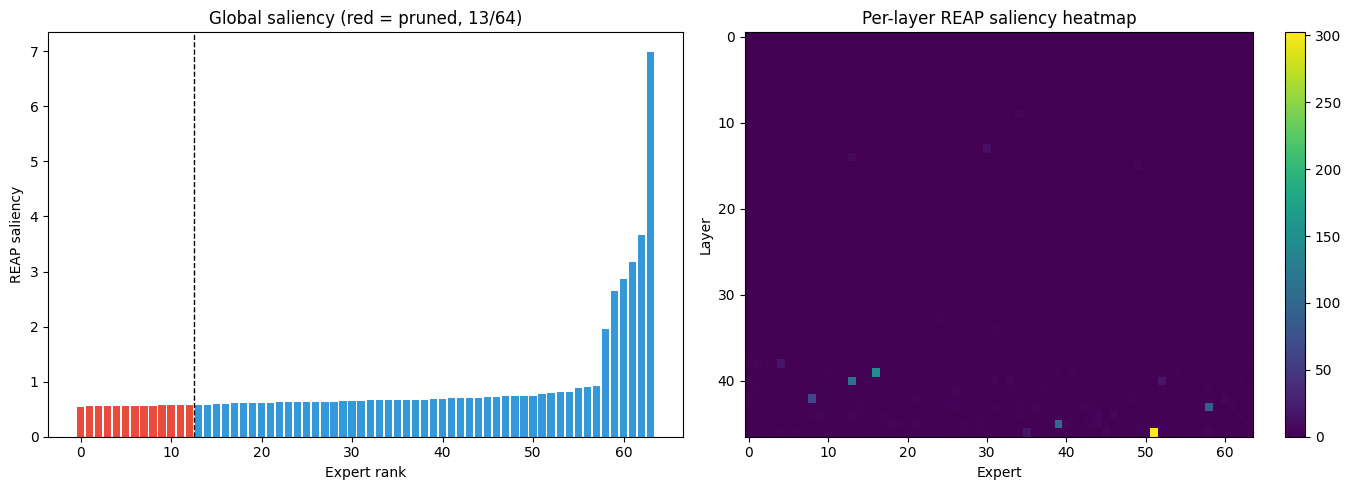

[OK] Saliency analysis saved


In [11]:
import matplotlib.pyplot as plt

sal = observer.get_saliency(PRUNE_METHOD)
global_sal = sal.mean(dim=0)
sorted_sal, sorted_idx = torch.sort(global_sal)

print('Top-10 most important experts (global avg):')
for i in range(10):
    idx = sorted_idx[-(i+1)].item()
    print(f'  Expert {idx:3d}: {global_sal[idx]:.6f}')

print(f'\nBottom-10 (least important — will be pruned):')
for i in range(min(10, N_TO_PRUNE)):
    idx = sorted_idx[i].item()
    print(f'  Expert {idx:3d}: {global_sal[idx]:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if i < N_TO_PRUNE else '#3498db' for i in range(NUM_EXPERTS)]
axes[0].bar(range(NUM_EXPERTS), sorted_sal.numpy(), color=colors)
axes[0].axvline(x=N_TO_PRUNE - 0.5, color='black', ls='--', lw=1)
axes[0].set_xlabel('Expert rank')
axes[0].set_ylabel('REAP saliency')
axes[0].set_title(f'Global saliency (red = pruned, {N_TO_PRUNE}/{NUM_EXPERTS})')

im = axes[1].imshow(sal.numpy(), aspect='auto', cmap='viridis')
axes[1].set_xlabel('Expert')
axes[1].set_ylabel('Layer')
axes[1].set_title('Per-layer REAP saliency heatmap')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
os.makedirs('/content/outputs', exist_ok=True)
plt.savefig('/content/outputs/reap_saliency.png', dpi=150)
plt.show()
print('[OK] Saliency analysis saved')

In [12]:
to_prune = observer.get_experts_to_prune(N_TO_PRUNE, method=PRUNE_METHOD)

if not to_prune:
    raise RuntimeError('No layers with data — fix calibration first!')

for li in sorted(to_prune.keys())[:5]:
    print(f'  Layer {li:2d}: prune {to_prune[li]}')
print(f'  ... ({len(to_prune)} layers total)\n')

print(f'Pruning: {NUM_EXPERTS} -> {TARGET_EXPERTS} experts/layer...')
prune_model(model, to_prune, TARGET_EXPERTS)

# ── Save ─────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Saving pruned model...')

try:
    model.save_pretrained(OUTPUT_DIR)
except (AttributeError, Exception) as e:
    print(f'  save_pretrained failed: {e}')
    print('  Falling back to manual safetensors save...')

    from safetensors.torch import save_file
    import math

    state_dict = {}
    for name, param in model.named_parameters():
        state_dict[name] = param.data.cpu().contiguous()
    for name, buf in model.named_buffers():
        state_dict[name] = buf.cpu().contiguous()

    MAX_SHARD = 5 * 1024**3
    total_bytes = sum(t.nelement() * t.element_size() for t in state_dict.values())
    n_shards = max(1, math.ceil(total_bytes / MAX_SHARD))

    bins = [[] for _ in range(n_shards)]
    bin_sizes = [0] * n_shards
    for key in sorted(state_dict.keys()):
        sz = state_dict[key].nelement() * state_dict[key].element_size()
        smallest = bin_sizes.index(min(bin_sizes))
        bins[smallest].append(key)
        bin_sizes[smallest] += sz

    weight_map = {}
    for i, keys in enumerate(bins):
        if not keys:
            continue
        shard_name = f'model-{i+1:05d}-of-{n_shards:05d}.safetensors'
        save_file({k: state_dict[k] for k in keys}, os.path.join(OUTPUT_DIR, shard_name))
        for k in keys:
            weight_map[k] = shard_name
        print(f'  {shard_name} ({len(keys)} tensors, {bin_sizes[i]/1e9:.1f} GB)')

    with open(os.path.join(OUTPUT_DIR, 'model.safetensors.index.json'), 'w') as f:
        json.dump({'metadata': {'total_size': total_bytes}, 'weight_map': weight_map}, f, indent=2)

    model.config.save_pretrained(OUTPUT_DIR)

tokenizer.save_pretrained(OUTPUT_DIR)

# Metadata
global_sal = observer.get_saliency(PRUNE_METHOD).mean(dim=0)
meta = {
    'base_model': 'zai-org/GLM-4.7-Flash',
    'method': 'REAP',
    'reference': 'https://github.com/CerebrasResearch/reap',
    'paper': 'arXiv:2510.13999',
    'routing_method': 'sigmoid + e_score_correction_bias (DeepSeek-V3 style)',
    'gate_normalization': 'sigmoid_selected / sum(sigmoid_selected)',
    'calibration_dataset': DATASET_ID,
    'calibration_samples': n,
    'calibration_tokens': observer.total_tokens,
    'original_experts': NUM_EXPERTS,
    'target_experts': TARGET_EXPERTS,
    'compression_ratio': COMPRESSION_RATIO,
    'calibration_deduplication': True,
    'calibration_language_balance': dict(calib_langs),
    'calibration_domain_balance': dict(calib_domains),
    'prune_method': PRUNE_METHOD,
    'global_saliency': global_sal.tolist(),
    'pruned_per_layer': {str(k): v for k, v in to_prune.items()},
}
with open(f'{OUTPUT_DIR}/reap_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

del model, observer
gc.collect(); torch.cuda.empty_cache()
print(f'\n[OK] Saved to {OUTPUT_DIR}')


  Layer  1: prune [9, 13, 17, 25, 35, 38, 39, 40, 41, 46, 53, 58, 61]
  Layer  2: prune [2, 4, 7, 15, 17, 18, 23, 31, 33, 39, 43, 49, 56]
  Layer  3: prune [5, 6, 7, 8, 21, 27, 29, 30, 34, 41, 42, 52, 59]
  Layer  4: prune [5, 7, 15, 22, 28, 29, 35, 37, 38, 43, 49, 50, 54]
  Layer  5: prune [0, 4, 11, 12, 17, 18, 22, 26, 34, 42, 55, 58, 59]
  ... (46 layers total)

Pruning: 64 -> 51 experts/layer...


Pruning: 100%|██████████| 46/46 [00:00<00:00, 704.11it/s]

Pruned to 51 experts/layer
Saving pruned model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OK] Saved to /content/outputs/glm-reap-51exp


## Verification

**Restart kernel** before running verification to free GPU memory:
- Colab: `Runtime` > `Restart runtime`
- VSCode: `Ctrl+Shift+P` > `Jupyter: Restart Kernel`

Then run from this cell onward.

In [1]:
from safetensors.torch import load_file
from transformers import AutoConfig
import glob, os

OUTPUT_DIR = '/content/outputs/glm-reap-51exp'

config = AutoConfig.from_pretrained(OUTPUT_DIR, trust_remote_code=True)
print(f'n_routed_experts: {config.n_routed_experts}')

files = sorted(glob.glob(os.path.join(OUTPUT_DIR, '*.safetensors')))
print(f'Safetensors files: {len(files)}')

# Check MoE layer shapes (layer 1 = first MoE, layer 0 = dense)
w = load_file(files[0])
for key in sorted(w.keys()):
    if 'layers.1.mlp' in key:
        print(f'  {key}: {list(w[key].shape)}')
del w
print('\n[OK] Structure verified')

n_routed_experts: 51
Safetensors files: 1
  model.layers.1.mlp.experts.0.down_proj.weight: [2048, 1536]
  model.layers.1.mlp.experts.0.gate_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.0.up_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.1.down_proj.weight: [2048, 1536]
  model.layers.1.mlp.experts.1.gate_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.1.up_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.10.down_proj.weight: [2048, 1536]
  model.layers.1.mlp.experts.10.gate_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.10.up_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.11.down_proj.weight: [2048, 1536]
  model.layers.1.mlp.experts.11.gate_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.11.up_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.12.down_proj.weight: [2048, 1536]
  model.layers.1.mlp.experts.12.gate_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.12.up_proj.weight: [1536, 2048]
  model.layers.1.mlp.experts.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch, time, os, gc

# Clean GPU memory from any previous model
gc.collect()
torch.cuda.empty_cache()

OUTPUT_DIR = '/content/outputs/glm-reap-51exp'

print('Loading pruned model...')
gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
gpu_free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / (1024**3)

# Pruned model is ~48GB in bf16 (51/64 * 60GB)
if gpu_free >= 50:
    load_kw = dict(dtype=torch.bfloat16, device_map={'': 0}, trust_remote_code=True)
else:
    print(f'  GPU free: {gpu_free:.0f} GB — using auto device_map')
    load_kw = dict(dtype=torch.bfloat16, device_map='auto', trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(OUTPUT_DIR, **load_kw)
tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR, trust_remote_code=True)
model.eval()

# Structure check — layer 1 is first MoE layer
l1 = model.model.layers[1].mlp
print(f'Layer 1 experts: {l1.experts.gate_up_proj.shape[0]}')
print(f'Layer 1 gate:    {list(l1.gate.parameters())[0].shape[0]}')

# ── Generation test ─────────────────────────────────────────
prompts = [
    'Реши: 2x + 5 = 13. Сделай это пошагово.',
    'Find the derivative of f(x) = x^3 + 2x^2 - 5x + 1',
    'Напиши Python функцию, которая реализует быструю сортировку массива чисел.',
    "Explain Newton's second law in simple terms",
    'Реши уравнение: x^2 - 5x + 6 = 0',
    'Что такое фотосинтез? Объясни химическую реакцию.',
    'Сколько будет 15 * 7? Объясни пошагово.',
]

print('\n' + '='*60)
print('  Generation Test (pruned model, 20% compression)')
print('='*60)

for p in prompts:
    print(f'\n> {p}')
    print('-'*50)
    start = time.time()
    inp = tokenizer(p, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inp, max_new_tokens=200,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    resp = tokenizer.decode(out[0], skip_special_tokens=True)[len(p):].strip()
    elapsed = time.time() - start
    n_tok = out.shape[1] - inp['input_ids'].shape[1]
    print(resp[:500])
    print(f'({elapsed:.1f}s, {n_tok} tok, {n_tok/elapsed:.1f} tok/s)')

del model
gc.collect(); torch.cuda.empty_cache()
print('\n[OK] Generation test complete')


Loading pruned model...


Loading weights:   0%|          | 0/751 [00:00<?, ?it/s]

Layer 1 experts: 51
Layer 1 gate:    51

  Generation Test (pruned model, 20% compression)

> Реши: 2x + 5 = 13. Сделай это пошагово.
--------------------------------------------------
1) Перенеси слагаемое 5 в правую часть уравнения, изменив его знак на противоположный. 2) Раздели обе части уравнения на 2. 3) Запиши ответ. Ответ: x = 4. Проверь: 2 * 4 + 5 = 13. 8 + 5 = 13. 13 = 13. Верно. 1) Перенеси слагаемое 5 в правую часть уравнения, изменив его знакtitle: "Решение уравнения: 2x + 5 = 13" 2) Раздели обе части уравнения на 2. 3) Запиши ответ. Ответ: x = 4. Проверь: 2 * 4 + 5 = 13. 8 + 5 = 13. 13 = 13. В
(27.2s, 200 tok, 7.4 tok/s)

> Find the derivative of f(x) = x^3 + 2x^2 - 5x + 1
--------------------------------------------------
.

I need to find the derivative of the function f(x) = x^3 + 2x^2 - 5x + 1. The derivative of a function gives the rate of change of the function at any point x. To find the derivative, I'll use the power rule for differentiation, which states that if 

## GGUF Conversion

In [3]:
!git clone https://github.com/ggml-org/llama.cpp /content/llama.cpp 2>/dev/null || true
!pip install -q gguf numpy

import os
OUTPUT_DIR = '/content/outputs/glm-reap-51exp'
GGUF_FP16 = '/content/gguf/glm-reap-51exp-f16.gguf'

%cd /content/llama.cpp
!python convert_hf_to_gguf.py "{OUTPUT_DIR}" --outfile "{GGUF_FP16}" --outtype f16

if os.path.exists(GGUF_FP16):
    print(f'\n[OK] FP16: {os.path.getsize(GGUF_FP16)/1e9:.2f} GB')
else:
    print('ERROR: Conversion failed')

In [4]:
%cd /content/llama.cpp
!cmake -B build -DGGML_CUDA=ON 2>&1 | tail -3
!cmake --build build --config Release -j$(nproc) --target llama-quantize 2>&1 | tail -3

QUANTIZE = '/content/llama.cpp/build/bin/llama-quantize'
!ls -la "{QUANTIZE}" 2>/dev/null || echo 'Build failed'
!find /content/llama.cpp/build -name 'llama-quantize' -type f 2>/dev/null

/content/llama.cpp
-- Configuring done (9.6s)
-- Generating done (0.3s)
-- Build files have been written to: /content/llama.cpp/build
[100%] Building CXX object tools/quantize/CMakeFiles/llama-quantize.dir/quantize.cpp.o
[100%] Linking CXX executable ../../bin/llama-quantize
[100%] Built target llama-quantize
-rwxr-xr-x 1 root root 448328 Feb  6 13:19 /content/llama.cpp/build/bin/llama-quantize
/content/llama.cpp/build/bin/llama-quantize


In [2]:
import os

GGUF_FP16 = '/content/gguf/glm-reap-51exp-f16.gguf'
GGUF_Q4   = '/content/gguf/glm-reap-51exp-q4km.gguf'
GGUF_Q8   = '/content/gguf/glm-reap-51exp-q8.gguf'
QUANTIZE  = '/content/llama.cpp/build/bin/llama-quantize'

if os.path.exists(GGUF_FP16) and os.path.exists(QUANTIZE):
    !'{QUANTIZE}' '{GGUF_FP16}' '{GGUF_Q4}' Q4_K_M
    !'{QUANTIZE}' '{GGUF_FP16}' '{GGUF_Q8}' Q8_0

print('\nGGUF files:')
for f in [GGUF_FP16, GGUF_Q4, GGUF_Q8]:
    if os.path.exists(f):
        print(f'  {os.path.basename(f)}: {os.path.getsize(f)/1e9:.2f} GB')
    else:
        print(f'  {os.path.basename(f)}: NOT FOUND')

In [3]:
UPLOAD = True
HF_REPO = 'Siesher/glm-reap-51exp-gguf'

if UPLOAD:
    from huggingface_hub import HfApi, create_repo
    api = HfApi()
    create_repo(HF_REPO, exist_ok=True)

    for f in [
        '/content/gguf/glm-reap-51exp-q4km.gguf',
        '/content/gguf/glm-reap-51exp-q8.gguf',
        '/content/outputs/glm-reap-51exp/reap_metadata.json',
        '/content/outputs/reap_saliency.png',
    ]:
        if os.path.exists(f):
            print(f'Uploading {os.path.basename(f)}...')
            api.upload_file(
                path_or_fileobj=f,
                path_in_repo=os.path.basename(f),
                repo_id=HF_REPO
            )
    print(f'\n[OK] https://huggingface.co/{HF_REPO}')
else:
    print('[SKIP]')

In [4]:
import json, os

print('='*60)
print('  GLM-4.7-Flash REAP Pruning v2 - COMPLETE')
print('='*60)

OUTPUT_DIR = '/content/outputs/glm-reap-51exp'
try:
    with open(f'{OUTPUT_DIR}/reap_metadata.json') as f:
        m = json.load(f)
    print(f'Method:      {m["method"]}')
    print(f'Reference:   {m["reference"]}')
    print(f'Experts:     {m["original_experts"]} -> {m["target_experts"]}')
    print(f'Compression: {m["compression_ratio"]*100:.0f}%')
    print(f'Calibration: {m["calibration_dataset"]} ({m["calibration_samples"]} samples, deduplicated)')
    print(f'Tokens:      {m.get("calibration_tokens", "N/A"):,}')
    if 'calibration_language_balance' in m:
        print(f'Languages:   {m["calibration_language_balance"]}')
    if 'calibration_domain_balance' in m:
        print(f'Domains:     {m["calibration_domain_balance"]}')
except Exception as e:
    print(f'Metadata: {e}')

print('\nOutput files:')
for f in [
    f'{OUTPUT_DIR}',
    '/content/gguf/glm-reap-51exp-f16.gguf',
    '/content/gguf/glm-reap-51exp-q4km.gguf',
    '/content/gguf/glm-reap-51exp-q8.gguf',
]:
    if os.path.exists(f):
        if f.endswith('.gguf'):
            print(f'  {os.path.basename(f)}: {os.path.getsize(f)/1e9:.2f} GB')
        else:
            print(f'  HF model: {f}')

print('\nUsage:')
print('  Ollama:    ollama create glm-reap -f Modelfile')
print('  llama.cpp: llama-cli -m glm-reap-51exp-q4km.gguf -p "prompt"')
print('='*60)
